JUEGO "ADIVINA EL NÚMERO" 


1. Partida Modo Solitario 
2. Partida 2 jugadores 
3. Estadística 
4. Salir


Elige una opción: 3


Opción válida
Estadísticas de partidas:
Jugador: Nicolas - Resultado: Perdido - Intentos: 5
Jugador: Juan - Resultado: Perdido - Intentos: 5
Jugador: Juan - Resultado: Ganado - Intentos: 1
Jugador: Rosa - Resultado: Perdido - Intentos: 20
Jugador: Jose Luis - Resultado: Perdido - Intentos: 5
Jugador: Natalia - Resultado: Ganado - Intentos: 4
Jugador: Miguel - Resultado: Perdido - Intentos: 5
Jugador: Juan - Resultado: Ganado - Intentos: 2
Jugador: Elena - Resultado: Ganado - Intentos: 4
Jugador: Manuel - Resultado: Ganado - Intentos: 1
Jugador: Luis - Resultado: Ganado - Intentos: 4
Jugador: Rebeca - Resultado: Perdido - Intentos: 5
Jugador: Rebeca - Resultado: Perdido - Intentos: 5
Jugador: Rebeca - Resultado: Ganado - Intentos: 2
Jugador: Sara - Resultado: Ganado - Intentos: 2
Jugador: Rebeca - Resultado: Ganado - Intentos: 12
Jugador: Rebeca - Resultado: Ganado - Intentos: 11


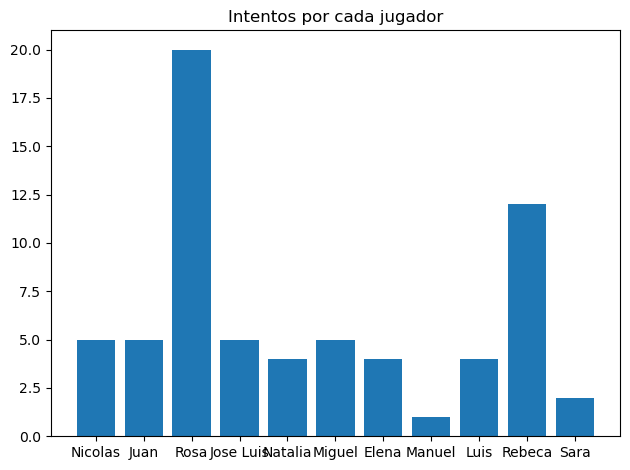

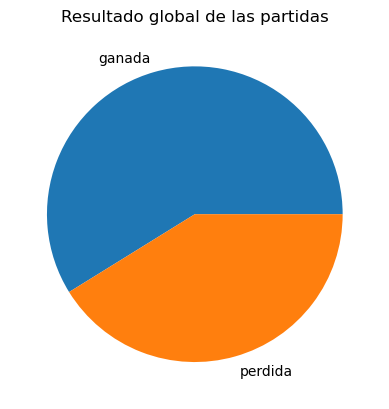

In [2]:
import Utilidades
import openpyxl
import matplotlib.pyplot as grafico
import getpass



def Dificultad(dificultad): 
    if dificultad == 1: 
        return 20
    if dificultad == 2:
        return 12
    if dificultad == 3:
        return 5

def Resultados(ganar):
    if ganar: 
        return "Ganado" 

    else:
        return "Perdido"

def juego(numero, maximos_intentos):
    intentos = 0
    ganar = False 
    
    for n in range(maximos_intentos):
        numero1 = int(input("Introduce un número:"))
                      
        while numero1 < 1 or numero1 > 1000:
            numero1 = int(input("El número no es válido, introduce un número entre 1 y 1000: "))
        intentos += 1
        
        if numero1 > numero:
            print("El número introducido es mayor") 
        elif numero1 < numero: 
            print("El número introducido es menor")
        elif numero1 == numero:
            print("¡Enhorabuena, has acertado!") 
            ganar = True  
            break         
        else: 
            print("Lo siento, has perdido")  

    return ganar, intentos 

def GuardarExcel(nombre, resultado, intentos):
    excel_document = openpyxl.load_workbook(r'C:\EjerciciosPython\Tarea 1 - Adivina el número.xlsx')
    hoja = excel_document["RESULTADOS"]
    hoja.append([nombre, resultado, intentos])
    excel_document.save(r'C:\EjerciciosPython\Tarea 1 - Adivina el número.xlsx')
    print(f"Datos guardados en Excel...")

def MostrarEstadisticas():
    excel_document = openpyxl.load_workbook(r'C:\EjerciciosPython\Tarea 1 - Adivina el número.xlsx')
    hoja = excel_document["RESULTADOS"]
    
    print("Estadísticas de partidas:")
    fila = 2 
       
    nombre_total =[]   #guardamos los datos en una lista para evitar quedarnos con el último valor cuando mostremos los gráficos 
    resultados_total = []
    intentos_total = []
    
    while hoja["A" + str(fila)].value != None:
        nombre = hoja["A" + str(fila)].value
        resultado = hoja["B" + str(fila)].value
        intentos = hoja["C" + str(fila)].value
        print("Jugador:", nombre, "- Resultado:", resultado, "- Intentos:", intentos)
            
        nombre_total.append(nombre)
        resultados_total.append(resultado)
        intentos_total.append(intentos)
            
        fila += 1
        
    grafico.bar(nombre_total, intentos_total)
    grafico.title("Intentos por cada jugador")
    grafico.tight_layout()
    grafico.show()

    grafico.pie([resultados_total.count("Ganado"), resultados_total.count("Perdido")], labels =["ganada","perdida"])
    grafico.title("Resultado global de las partidas")
    grafico.show()



def AdivinaNumero():
    print("1. Partida Modo Solitario \n2. Partida 2 jugadores \n3. Estadística \n4. Salir") 
    opcion = int(input("Elige una opción:"))



        
#                                                 MENÚ PRINCIPAL 

#Elige opción
    
    while opcion < 1 or opcion > 4: #creamos bucle para pedir opción correcta
        print("Opción no válida")
        opcion = int(input("Elige otra opción: "))
    print("Opción válida")

    if opcion == 4:
        print("Saliendo del juego...")
        return

#Pedimos dificultad

    if opcion in [1,2]:
        print("Dificultad: \n1. Fácil (20 intentos) \n2. Medio (12 intentos) \n3. Difícil (5 intentos)")
        dificultad = int(input("Elige dificultad:"))     
        while dificultad < 1 or dificultad > 3:
            print("Opción no válida")
            dificultad = int(input("Elige otra opción: "))
        
        maximos_intentos = Dificultad(dificultad)
        print("Opción válida")

#                                                 JUEGO 
    
#Modo solitario

    if opcion == 1:
        numero = Utilidades.DameAleatorio(1, 1000) #llamamos al módulo Utilidades creado previamente y a la función para obtener un número aleatorio
        ganar, intentos = juego(numero, maximos_intentos)
    
        
        nombre = input("Introduce tu nombre:")
        resultado = Resultados(ganar)
        GuardarExcel(nombre, resultado, intentos)

    
#Modo 2 jugadores
    
    if opcion == 2:     
        j1 = int(getpass.getpass("Jugador 1 introduce un número:"))
        while j1 < 1 or j1 > 1000:
            j1 = int(getpass.getpass("Número inválido, introduce un número entre 1 y 1000: "))
            
        ganar, intentos = juego(j1,maximos_intentos)

        nombre = input("Introduce tu nombre:")
        resultado = Resultados(ganar)
        GuardarExcel(nombre, resultado, intentos)
        


#                                         ESTADÍSTICAS + GRÁFICO 

    if opcion == 3:
        MostrarEstadisticas()
       

    
AdivinaNumero()